# 01 · Exploratory data analysis

What can this dataset tell us about card fraud, and what can it not tell us?

The brief asks for a classifier. Before modelling, this notebook establishes (1) data quality and which fields carry information, (2) where fraud concentrates, (3) whether time carries signal, and (4) two findings that shape the design: fraud persists within an account, and merchants are perfectly nested inside categories.

All plotting and profiling code lives in the `fraud_detection` package (`data.py`, `plots.py`) so the same figures appear in the pipeline output and the report.

In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
FIG = ROOT / "reports" / "figures"
import tempfile
FIG_NB = Path(tempfile.mkdtemp())  # figures drawn in this notebook; the pipeline's own figures live in reports/figures
sys.path.insert(0, str(ROOT / "src"))
from fraud_detection.config import PipelineConfig, SplitConfig, CostAssumptions
from fraud_detection.data import load_raw, profile, clean
from fraud_detection.features import build_features, feature_columns, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from fraud_detection import plots
DATA = ROOT / "data" / "fraud.csv"

## 1. Load and profile

Values in the source file are wrapped in single quotes; the loader handles that. No missing values, no duplicate rows, and both zip-code fields are a single constant value.

In [2]:
raw = load_raw(DATA)
prof = profile(raw)
pd.Series(prof).to_frame("value")

,value
n_rows,594643
n_columns,10
n_missing_values,0
n_duplicate_rows,0
constant_columns,"[zipcodeOri, zipMerchant]"
n_steps,180
step_min,0
step_max,179
n_customers,4112
n_merchants,50


In [3]:
raw.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,es_transportation,4.5500,0
1,0,C352968107,2,M,28007,M348934600,28007,es_transportation,39.6800,0
2,0,C2054744914,4,F,28007,M1823072687,28007,es_transportation,26.8900,0
3,0,C1760612790,3,M,28007,M348934600,28007,es_transportation,17.2500,0
4,0,C757503768,5,M,28007,M348934600,28007,es_transportation,35.7200,0


## 2. Cleaning decisions

* Drop `zipcodeOri` and `zipMerchant` (constant).
* Cast `category`, `merchant`, `age`, `gender` to categorical.
* Keep `customer` as an identifier for building history features; it is **never** a model input.
* Keep the 52 zero-amount rows (all benign transportation and food), since they are legitimate and a production system would see them too.

In [4]:
df = clean(raw)
print(df.dtypes.to_string())
print("\nzero-amount rows by label:", df[df.amount == 0].fraud.value_counts().to_dict())

txn_id         int64
step           int32
customer         str
age         category
gender      category
merchant    category
category    category
amount       float64
fraud           int8

zero-amount rows by label: {0: 52}


## 3. Target: 1.2% positive rate

At this imbalance, accuracy is meaningless and even ROC-AUC saturates. The metrics that matter are precision-recall based, plus operational quantities (alerts per step, false positives per step).

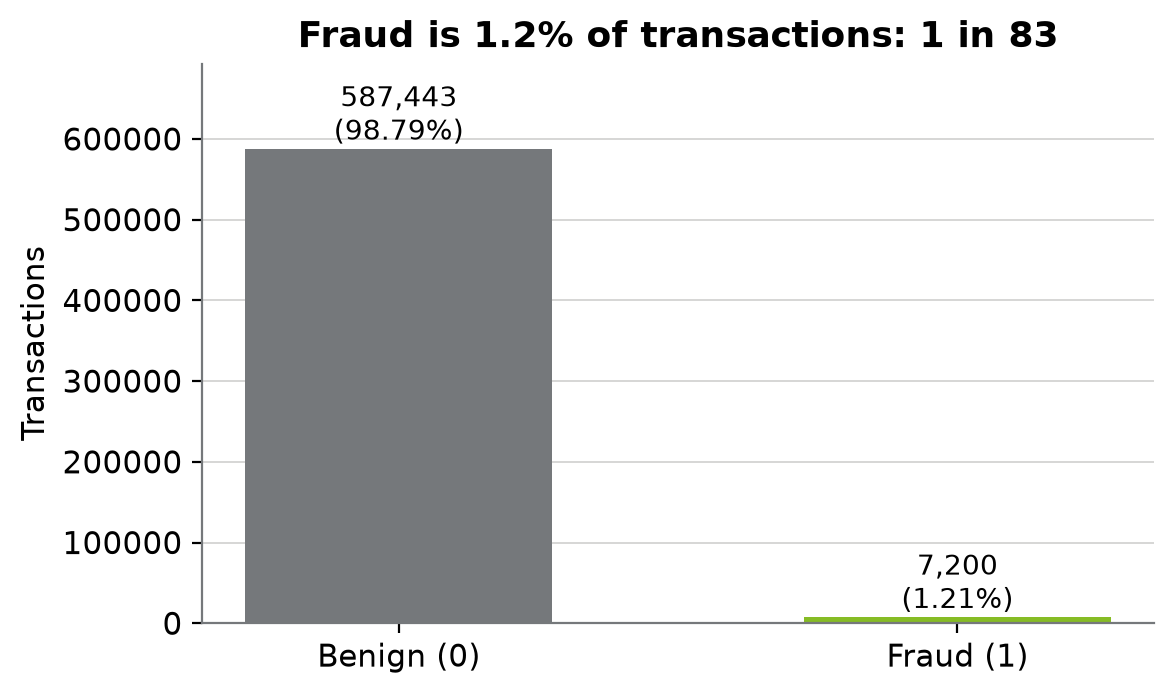

In [5]:
display(Image(plots.class_balance(df, FIG_NB / "eda_class_balance.png")))

## 4. Where fraud lives: category and merchant

Three categories carry no fraud at all and together make up ~90% of transaction volume. Fraud concentrates in low-volume categories (leisure, travel, sports & toys, hotel services). Each merchant belongs to exactly one category, so `merchant` refines `category` rather than adding an independent dimension.

In [6]:
cat = (df.groupby("category", observed=True)["fraud"].agg(transactions="size", fraud_count="sum", fraud_rate="mean")
         .assign(volume_share=lambda t: t.transactions / len(df))
         .sort_values("fraud_rate", ascending=False))
cat.style.format({"fraud_rate": "{:.1%}", "volume_share": "{:.2%}", "transactions": "{:,}", "fraud_count": "{:,}"})

,transactions,fraud_count,fraud_rate,volume_share
category,,,,
es_leisure,499,474,95.0%,0.08%
es_travel,728,578,79.4%,0.12%
es_sportsandtoys,"4,002","1,982",49.5%,0.67%
es_hotelservices,"1,744",548,31.4%,0.29%
es_otherservices,912,228,25.0%,0.15%
es_home,"1,986",302,15.2%,0.33%
es_health,"16,133","1,696",10.5%,2.71%
es_tech,"2,370",158,6.7%,0.40%
es_wellnessandbeauty,"15,086",718,4.8%,2.54%


merchants with more than one category: 0
merchants with zero fraud: 20 of 50


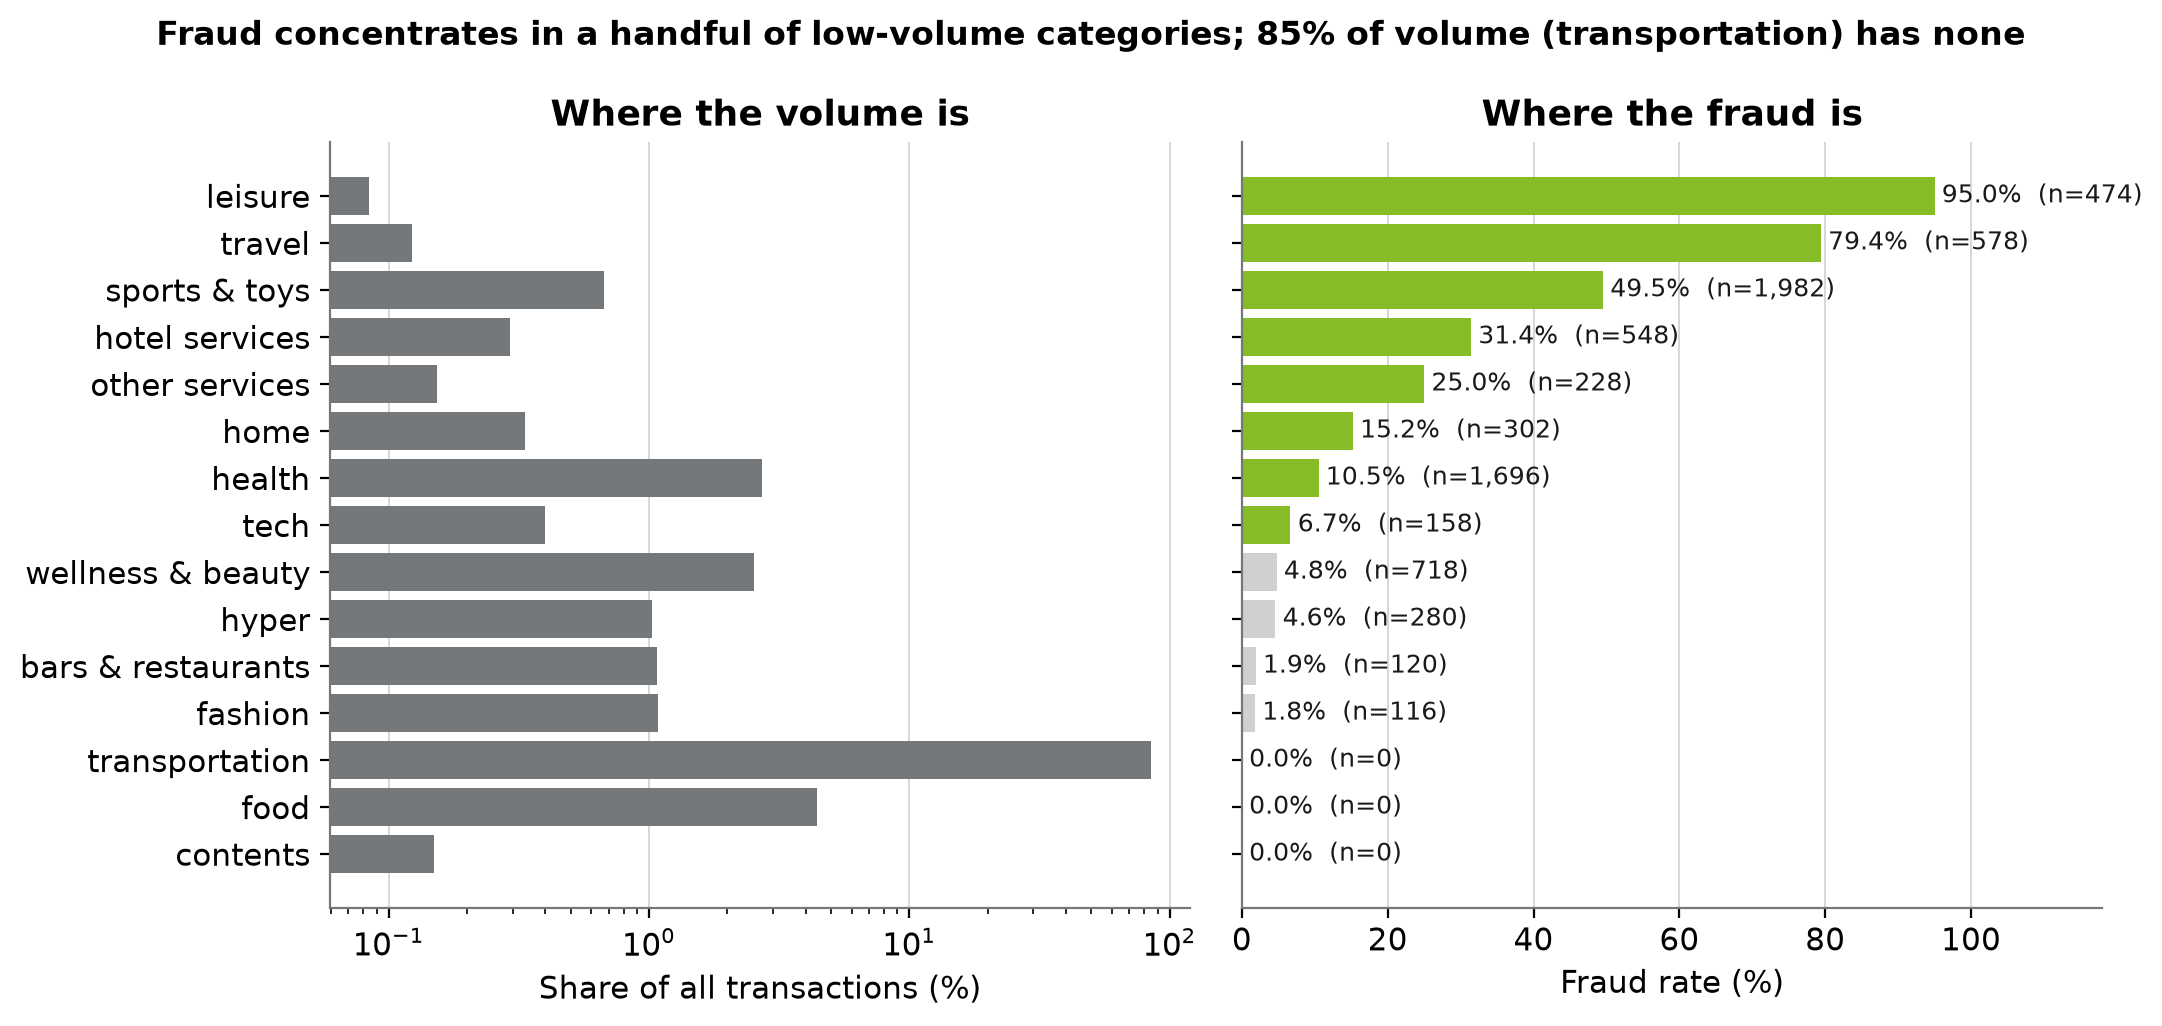

In [7]:
print("merchants with more than one category:", (df.groupby("merchant", observed=True).category.nunique() > 1).sum())
m = df.groupby("merchant", observed=True).fraud.agg(["size", "mean", "sum"]).sort_values("sum", ascending=False)
print("merchants with zero fraud:", int((m["sum"] == 0).sum()), "of", len(m))
display(Image(plots.fraud_by_category(df, FIG_NB / "eda_fraud_by_category.png")))

## 5. Amount: strong but not sufficient

Fraudulent transactions are roughly an order of magnitude larger. Within a risky category, however, amount alone separates fraud with an AUC of only ~0.85: a hotel bill of 300 is normal for some customers and alarming for others. This motivates *customer-relative* amount features.

             count     mean      50%        max
fraud                                          
0     587,443.0000  31.8472  26.6100 2,144.8600
1       7,200.0000 530.9266 319.1750 8,329.9600

AUC of amount alone, overall: 0.949
AUC of amount alone within category: {'es_barsandrestaurants': 0.844, 'es_fashion': 0.853, 'es_health': 0.843, 'es_home': 0.866, 'es_hotelservices': 0.855, 'es_hyper': 0.857, 'es_leisure': 0.995, 'es_otherservices': 0.877, 'es_sportsandtoys': 0.853, 'es_tech': 0.873, 'es_travel': 0.865, 'es_wellnessandbeauty': 0.84}


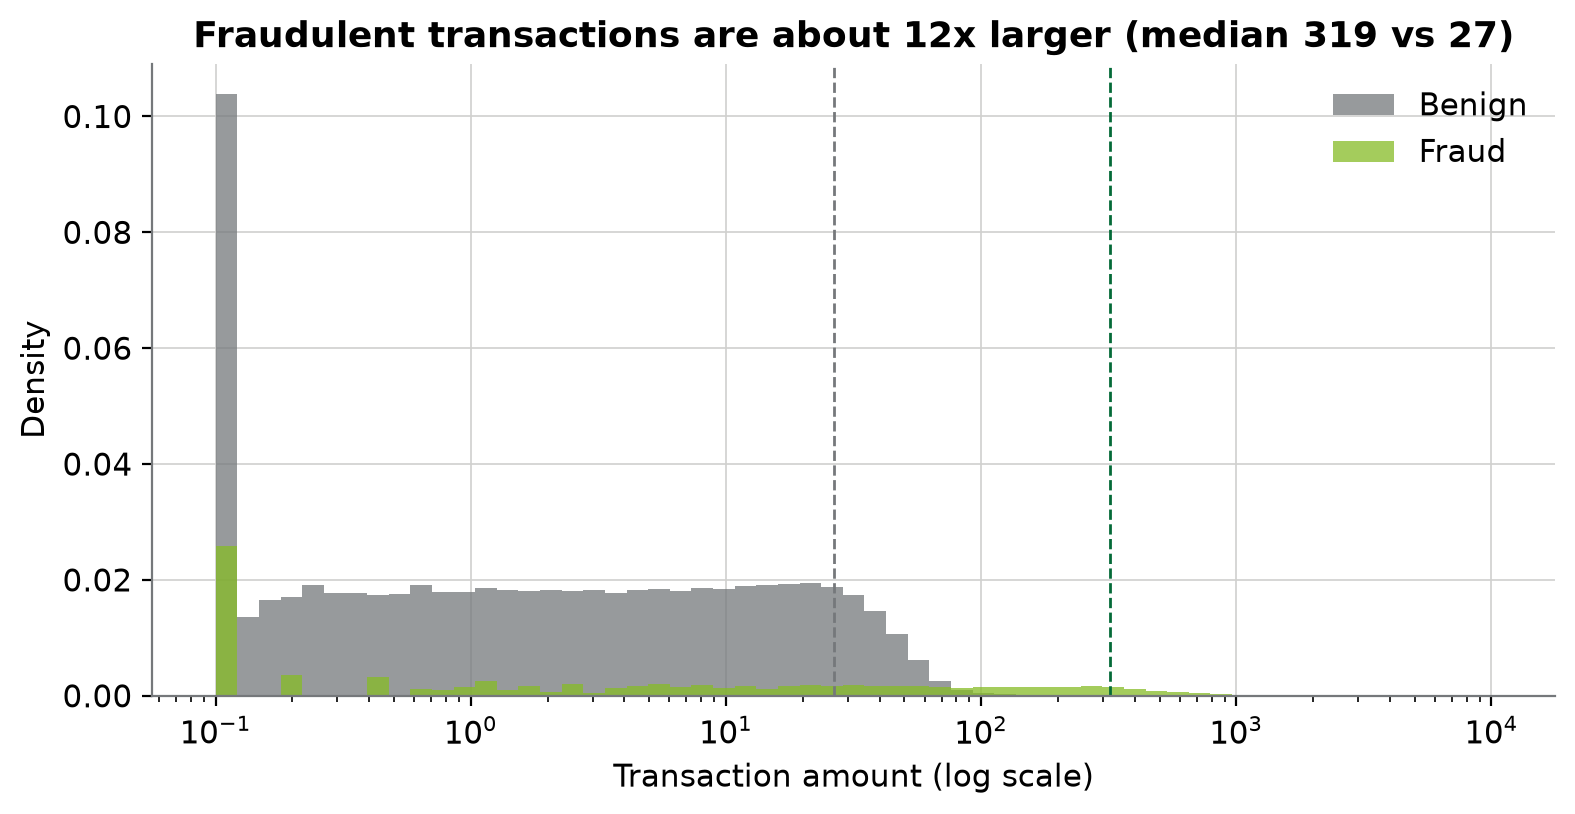

In [8]:
from sklearn.metrics import roc_auc_score
print(df.groupby("fraud").amount.describe()[["count", "mean", "50%", "max"]])
print("\nAUC of amount alone, overall:", round(roc_auc_score(df.fraud, df.amount), 3))
within = {c: round(roc_auc_score(g.fraud, g.amount), 3) for c, g in df.groupby("category", observed=True) if g.fraud.nunique() > 1}
print("AUC of amount alone within category:", within)
display(Image(plots.amount_distribution(df, FIG_NB / "eda_amount_distribution.png")))

## 5b. Fraud rate by amount band

Large amounts are rare and mostly fraudulent; the 500+ band is a natural rule and also the band where a missed fraud costs most.

**Outliers.** Amounts above 500 are 0.4% of transactions and 96% fraudulent, with a maximum of 8,330. They are kept, not clipped or removed: in fraud the extreme values are the signal, and tree models are unaffected by them. The 52 zero-amount rows are all benign and are kept as well.

In [9]:
from fraud_detection.evaluate import amount_band
bands = pd.DataFrame({"band": amount_band(df["amount"]), "fraud": df["fraud"].to_numpy()})
bands.groupby("band", observed=True)["fraud"].agg(transactions="size", fraud_count="sum", fraud_rate="mean").style.format({"fraud_rate": "{:.2%}", "transactions": "{:,}", "fraud_count": "{:,}"})

,transactions,fraud_count,fraud_rate
band,,,
0-50,"493,872",589,0.12%
50-100,"80,210",550,0.69%
100-250,"15,051","1,644",10.92%
250-500,"3,346","2,341",69.96%
500+,"2,164","2,076",95.93%


## 6. Time: no signal

The brief suggests deriving time-of-day from `step`. Fraud rate is flat across `step mod 24`, and the fraud *count* is exactly 40 in every step while volume grows. The features were still built and tested in the model ablation (see notebook 02) before being dropped.

unique fraud counts per step: [np.int8(40)]
fraud rate by hour-of-day (min, max): 0.0119 0.0123


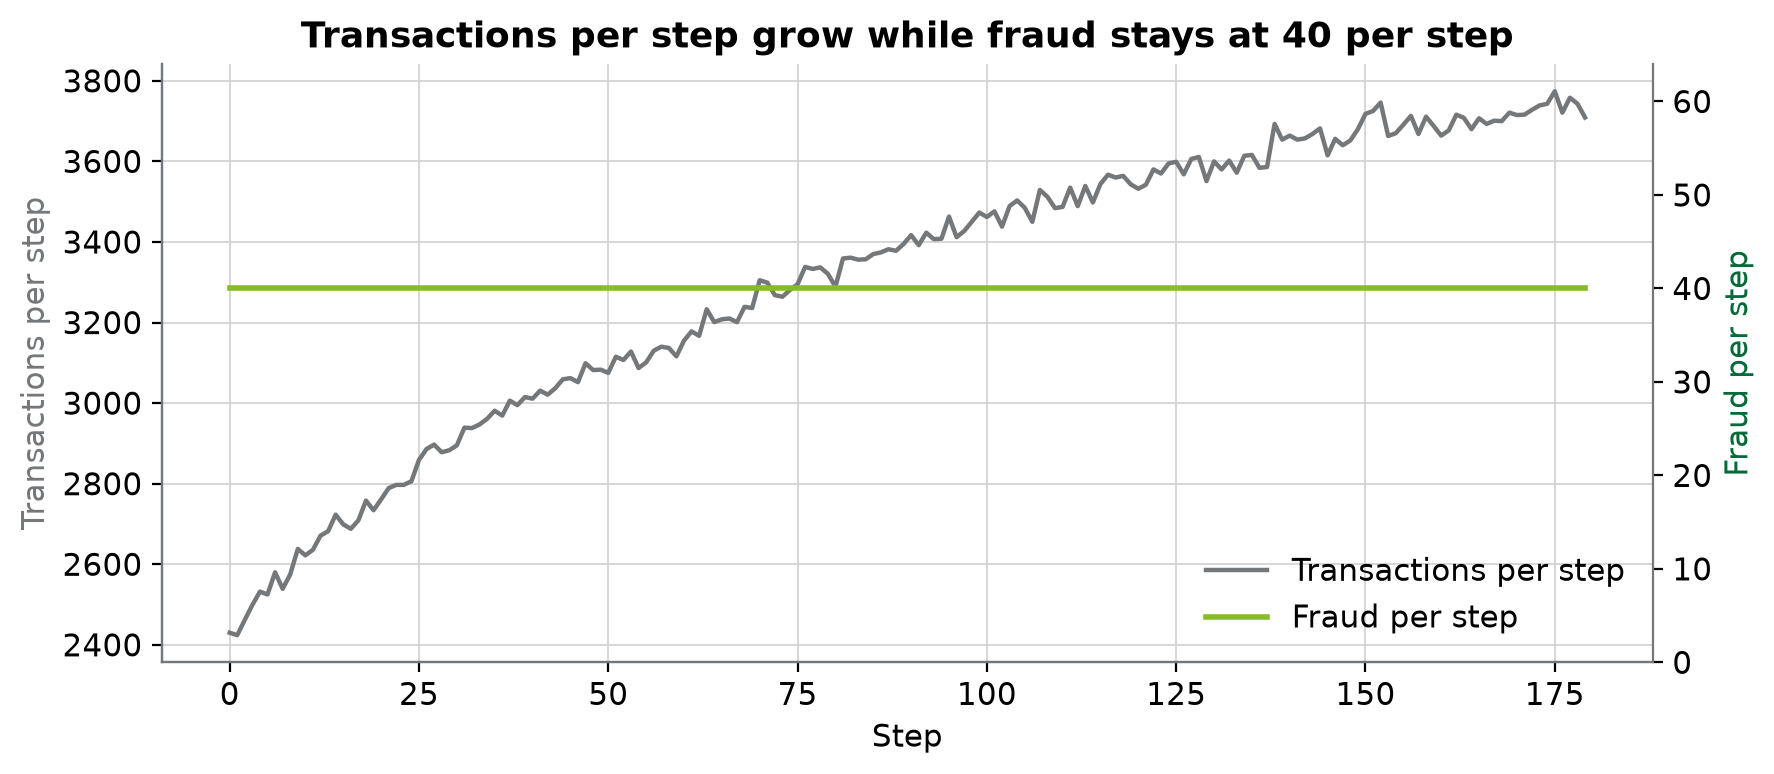

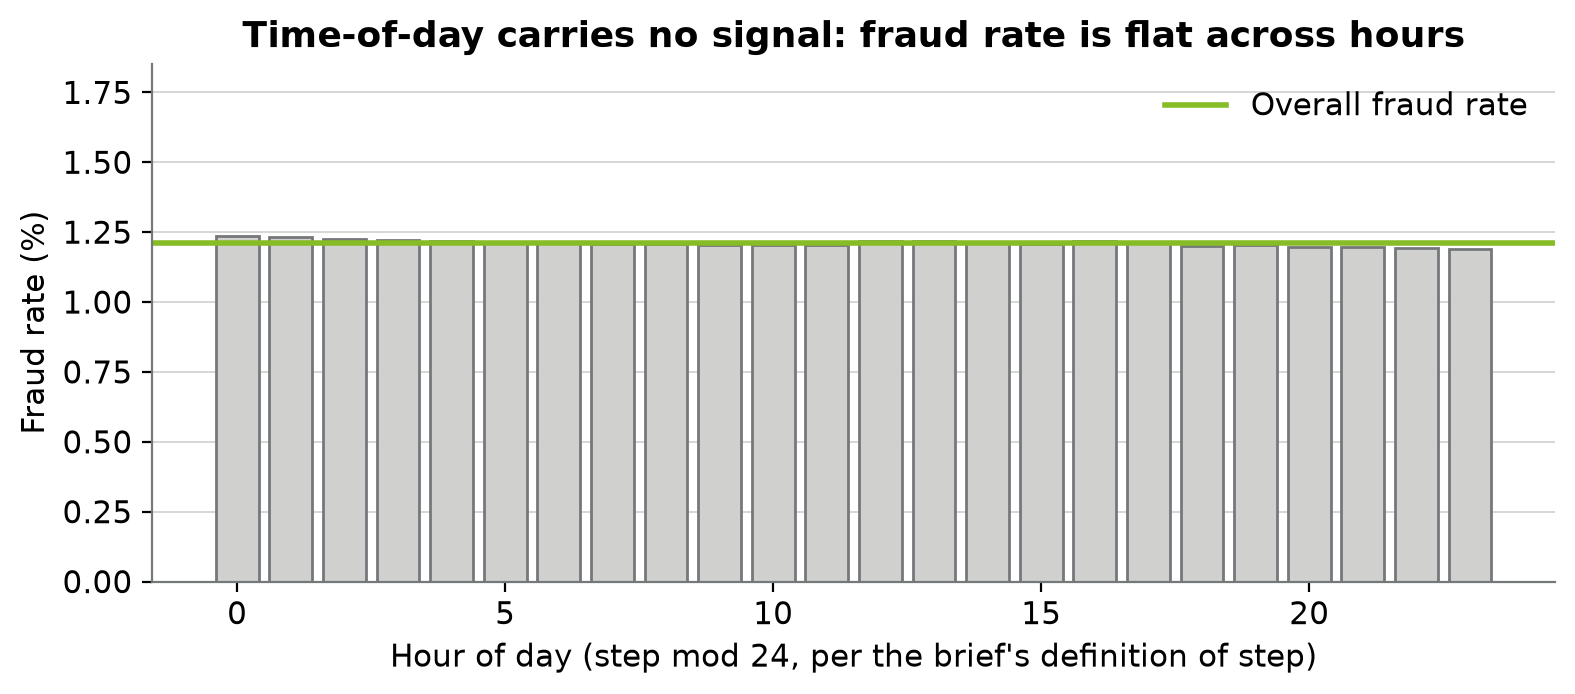

In [10]:
per_step = df.groupby("step").fraud.agg(["size", "sum"])
print("unique fraud counts per step:", sorted(per_step["sum"].unique()))
print("fraud rate by hour-of-day (min, max):", round((df.assign(h=df.step % 24).groupby("h").fraud.mean()).min(), 4), round((df.assign(h=df.step % 24).groupby("h").fraud.mean()).max(), 4))
display(Image(plots.fraud_over_time(df, FIG_NB / "eda_fraud_over_time.png")))
display(Image(plots.hour_of_day(df, FIG_NB / "eda_hour_of_day.png")))

## 7. Fraud persists within an account

The transaction following a fraud is fraud ~36% of the time versus <1% otherwise. A model could exploit this only if confirmed labels were available at scoring time; in reality they arrive weeks later (chargebacks). The model therefore does **not** use prior labels; the finding becomes an operational recommendation: block and reissue on confirmed fraud, step-up authentication on suspicion.

P(fraud | previous txn fraud) = 0.361   P(fraud | previous txn benign) = 0.0076   ratio = 48x


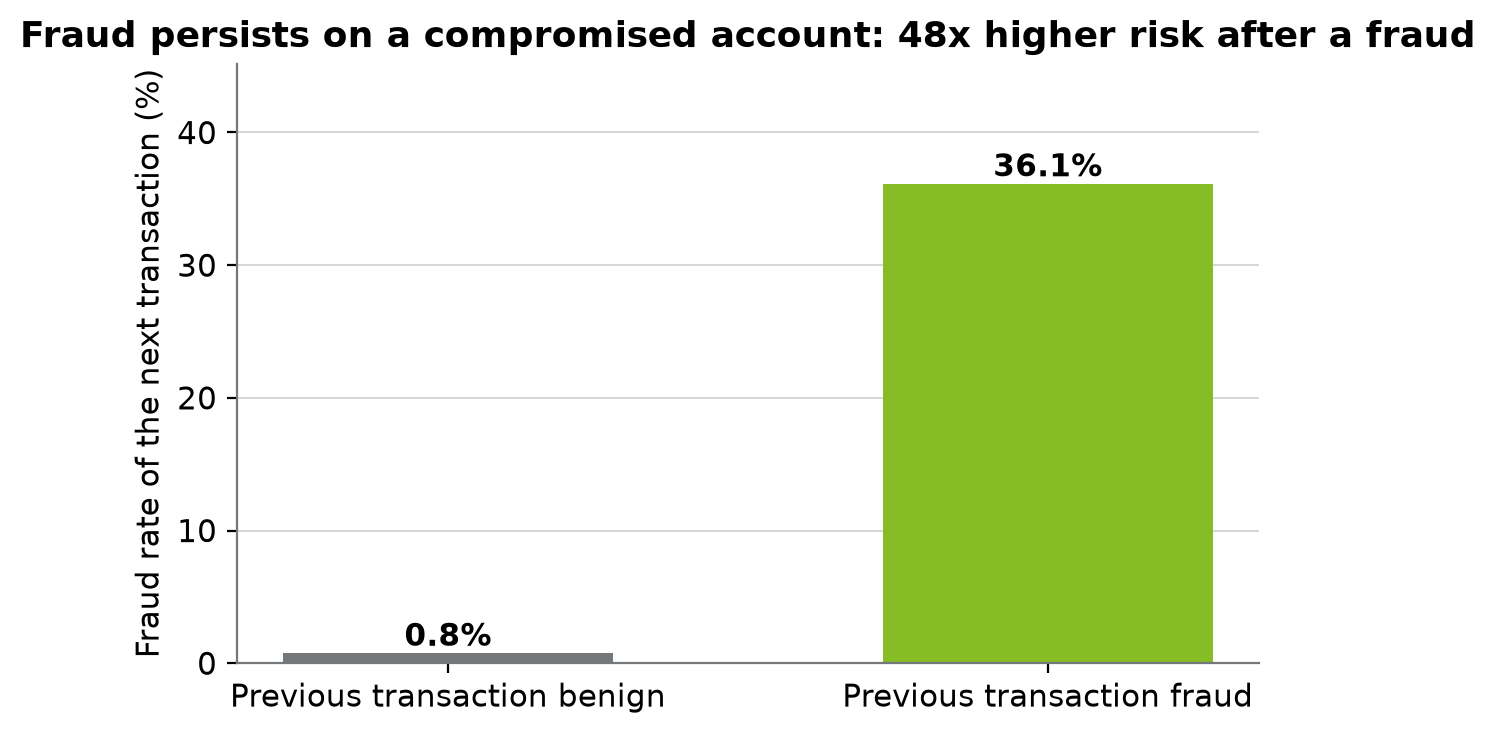

In [11]:
d = df.sort_values(["customer", "step"]).copy()
d["prev_fraud"] = d.groupby("customer", observed=True).fraud.shift(1)
rates = d.dropna(subset=["prev_fraud"]).groupby("prev_fraud").fraud.mean()
print(f"P(fraud | previous txn fraud) = {rates[1.0]:.3f}   P(fraud | previous txn benign) = {rates[0.0]:.4f}   ratio = {rates[1.0] / rates[0.0]:.0f}x")
display(Image(plots.customer_persistence(df, FIG_NB / "eda_customer_persistence.png")))

## 8. Protected attributes

Fraud rate differs by gender code (F 1.47% vs M 0.91%) and is highest for the under-18 band. Declining a payment is an adverse action; using protected characteristics to do so is a regulatory and reputational risk. These fields are tested as inputs in notebook 03 and excluded from the production model.

             n  fraud_rate
gender                    
E         1178      0.0059
F       324565      0.0147
M       268385      0.0091
U          515      0.0000 

          n  fraud_rate
age                    
0      2452      0.0196
1     58131      0.0119
2    187310      0.0125
3    147131      0.0119
4    109025      0.0129
5     62642      0.0110
6     26774      0.0097
U      1178      0.0059 



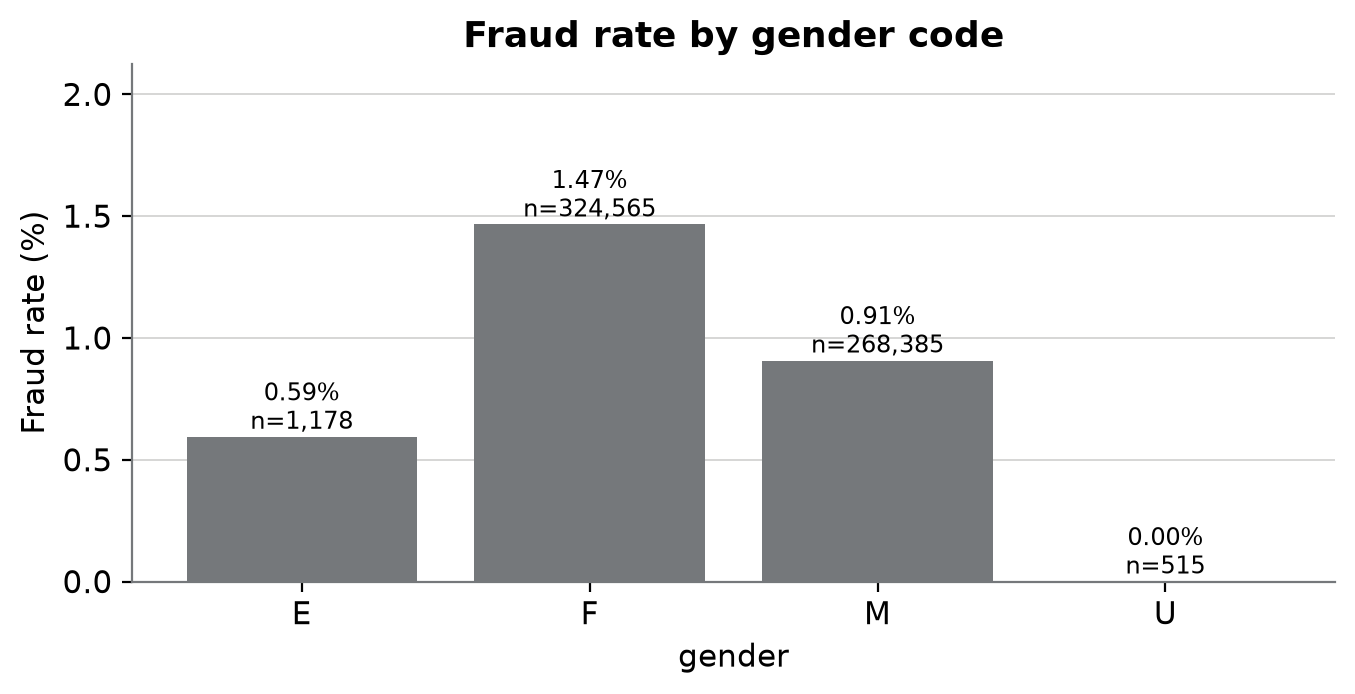

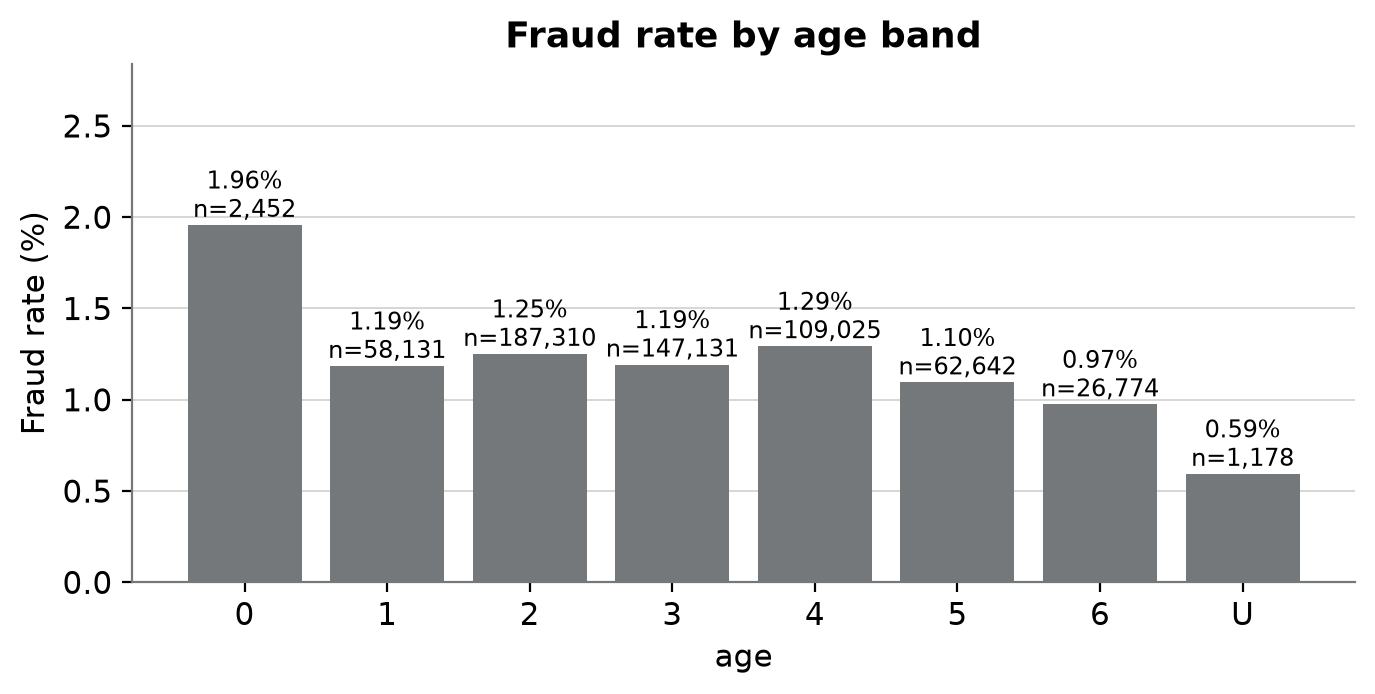

In [12]:
for col in ["gender", "age"]:
    print(df.groupby(col, observed=True).fraud.agg(n="size", fraud_rate="mean").round(4), "\n")
display(Image(plots.fraud_by_group(df, "gender", FIG_NB / "eda_fraud_by_gender.png", "Fraud rate by gender code")))
display(Image(plots.fraud_by_group(df, "age", FIG_NB / "eda_fraud_by_age.png", "Fraud rate by age band")))

## Findings that shape the design

| Finding | Design consequence |
|---|---|
| Constant zip codes | Dropped |
| Fraud concentrated by category; merchants nested in categories | `category` + `merchant` as categorical inputs; a category/amount rules baseline is a fair comparator |
| Amount separates fraud only partially within category | Customer-relative amount features (vs own mean/max/std), merchant- and category-relative amounts |
| No temporal signal; constant fraud injection | Time-of-day features tested then dropped; results are an upper bound to be re-validated on real traffic |
| Fraud persists within account | No label-derived features (label delay); operational block-and-reissue recommendation |
| Protected attributes | Tested, then excluded; group outcomes monitored |